In [1]:
!pip install yfinance pydantic requests

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- Config ---
TICKER = "AAPL"

def fetch_ohlcv(ticker: str, years: int = 2) -> pd.DataFrame:
    """
    Fetches daily OHLCV data for the given ticker.
    Uses dynamic date calculation - no hardcoded date strings.
    """
    end_date = datetime.today()
    start_date = end_date - timedelta(days=years * 365)

    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

    if df.empty:
        raise ValueError(f"No data returned for ticker: {ticker}")

    # Flatten multi-level columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.dropna(inplace=True)

    print(f"✅ Fetched {len(df)} rows for {ticker} from {df.index[0].date()} to {df.index[-1].date()}")
    return df

# --- Run it ---
df = fetch_ohlcv(TICKER)
df.tail()

[*********************100%***********************]  1 of 1 completed

✅ Fetched 499 rows for AAPL from 2024-05-06 to 2026-05-01


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-27,266.089996,268.359985,265.070007,267.609985,41466800
2026-04-28,272.339996,273.230011,268.660004,270.709991,40018900
2026-04-29,267.549988,271.040009,267.040009,270.170013,30047900
2026-04-30,270.500000,276.000000,268.140015,271.350006,91848200
2026-05-01,278.859985,287.220001,278.369995,280.140015,79844600


In [3]:
def compute_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes all 5 technical indicators from first principles.
    No TA-Lib used.
    """
    df = df.copy()

    # ── 1. SMA 50 & SMA 200 ──────────────────────────────────────
    # Simple average of closing price over N days
    df["SMA_50"] = df["Close"].rolling(window=50).mean()
    df["SMA_200"] = df["Close"].rolling(window=200).mean()

    # ── 2. RSI (14) — Wilder's Smoothing Method ──────────────────
    # Step 1: Calculate daily price changes
    delta = df["Close"].diff()

    # Step 2: Separate gains and losses
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Step 3: First average gain/loss uses simple mean (Wilder's init)
    window = 14
    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()

    # Step 4: RSI formula
    rs = avg_gain / avg_loss
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ── 3. MACD (12, 26, 9) ──────────────────────────────────────
    # MACD Line = 12-day EMA minus 26-day EMA
    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema_12 - ema_26

    # Signal Line = 9-day EMA of MACD line
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # Histogram = MACD minus Signal (shows momentum direction)
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    # ── 4. Bollinger Bands (20, 2std) ────────────────────────────
    rolling = df["Close"].rolling(window=20)
    df["BB_Middle"] = rolling.mean()
    df["BB_Std"]    = rolling.std()
    df["BB_Upper"]  = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"]  = df["BB_Middle"] - 2 * df["BB_Std"]

    print("✅ All 5 indicators computed successfully")
    print(f"   Columns: {[c for c in df.columns if c not in ['Open','High','Low','Close','Volume']]}")
    return df

# --- Run it ---
df = compute_indicators(df)
df[["Close", "SMA_50", "SMA_200", "RSI_14", "MACD", "BB_Upper", "BB_Lower"]].tail(10)

✅ All 5 indicators computed successfully
   Columns: ['SMA_50', 'SMA_200', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower']


Price,Close,SMA_50,SMA_200,RSI_14,MACD,BB_Upper,BB_Lower
Date,,,,,,,
2026-04-20,273.049988,260.501999,252.134105,66.533046,2.872127,271.322972,243.955025
2026-04-21,266.170013,260.268199,252.400445,56.723876,2.926444,272.241827,244.504171
2026-04-22,273.170013,260.239200,252.719730,62.742587,3.494055,274.416672,244.482327
2026-04-23,273.429993,260.234200,253.040015,62.948689,3.919685,276.326243,244.653756
2026-04-24,271.059998,260.145400,253.342818,59.706160,4.019427,277.481795,245.315204
2026-04-27,267.609985,260.262999,253.622040,55.244998,3.776553,277.493387,247.184610
2026-04-28,270.709991,260.561599,253.922993,58.262722,3.790524,277.194081,249.891915
2026-04-29,270.170013,260.687399,254.233908,57.534996,3.715197,277.505364,251.218633
2026-04-30,271.350006,260.827399,254.548280,58.747588,3.707972,277.968885,252.327112


In [4]:
def fetch_news(ticker: str, n: int = 10) -> list:
    """
    Fetches recent news headlines for the given ticker using yfinance.
    Handles missing fields gracefully.
    """
    try:
        stock = yf.Ticker(ticker)
        raw_news = stock.news

        if not raw_news:
            print(f"⚠️ No news returned for {ticker}")
            return []

        headlines = []
        for item in raw_news[:n]:
            # yfinance nests news content inside 'content' key
            content = item.get("content", {})
            title = content.get("title", "").strip()

            if not title:
                continue

            headlines.append({
                "title": title,
                "source": content.get("provider", {}).get("displayName", "Unknown"),
                "url": content.get("canonicalUrl", {}).get("url", ""),
                "published": content.get("pubDate", "")
            })

        print(f"✅ Fetched {len(headlines)} headlines for {ticker}")
        for i, h in enumerate(headlines, 1):
            print(f"  {i}. {h['title'][:80]}")

        return headlines

    except Exception as e:
        print(f"❌ News fetch failed: {e}")
        return []

# --- Run it ---
news = fetch_news(TICKER)

✅ Fetched 10 headlines for AAPL
  1. Dow Jones Futures Rise; Trump Says U.S. To 'Guide' Ships Through Hormuz
  2. This Under‑the‑Radar Grid Infrastructure Powerhouse Could Be a Generational Weal
  3. Apple Is Changing The Rules Right Before Tim Cook Exits
  4. Is Apple Inc. (AAPL) A Good Stock To Buy Now?
  5. Is It Too Late To Consider Apple (AAPL) After Its Strong Share Price Run?
  6. Should You Dump Bitcoin for Stocks After the S&P 500 Hit a New Record on Apple’s
  7. Jim Cramer on Apple: “You Had a Chance to Buy It After They Reported”
  8. Berkshire’s Greg Abel Marks His First Annual Meeting as CEO. We’d Give Him a B-P
  9. Anchor Loads Up Invesco BulletShares 2029 Corporate Bond ETF With 1.1 Million Sh
  10. Berkshire Investors Praise Greg Abel at Post-Buffett Meeting


In [5]:
def build_summary(ticker: str, df: pd.DataFrame, news: list) -> dict:
    """
    Builds a clean summary dictionary with all required fields.
    Handles missing/null values gracefully.
    """
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
    except Exception as e:
        print(f"⚠️ Could not fetch ticker info: {e}")
        info = {}

    # ── Current Price ─────────────────────────────────────────────
    current_price = df["Close"].iloc[-1]

    # ── 52-Week High / Low ────────────────────────────────────────
    one_year_ago = df.index[-1] - pd.DateOffset(days=365)
    df_52w = df[df.index >= one_year_ago]
    week_52_high = df_52w["High"].max()
    week_52_low  = df_52w["Low"].min()

    # ── Year-to-Date Return ───────────────────────────────────────
    current_year = df.index[-1].year
    df_ytd = df[df.index.year == current_year]
    if len(df_ytd) >= 2:
        ytd_return = ((df_ytd["Close"].iloc[-1] / df_ytd["Close"].iloc[0]) - 1) * 100
    else:
        ytd_return = None

    # ── P/E Ratio (may be None — handled gracefully) ──────────────
    pe_ratio = info.get("trailingPE", None)

    # ── Momentum Signal from Indicators ──────────────────────────
    latest = df.iloc[-1]
    signals = []

    # Golden cross check
    if latest["SMA_50"] > latest["SMA_200"]:
        signals.append("bullish_golden_cross")

    # RSI zone
    if latest["RSI_14"] > 70:
        signals.append("overbought_rsi")
    elif latest["RSI_14"] < 30:
        signals.append("oversold_rsi")
    else:
        signals.append("neutral_rsi")

    # MACD momentum
    if latest["MACD"] > latest["MACD_Signal"]:
        signals.append("bullish_macd")
    else:
        signals.append("bearish_macd")

    # Bollinger position
    if latest["Close"] > latest["BB_Upper"]:
        signals.append("price_above_bb_upper")
    elif latest["Close"] < latest["BB_Lower"]:
        signals.append("price_below_bb_lower")
    else:
        signals.append("price_within_bb")

    # Overall momentum
    bullish_count = sum(1 for s in signals if "bullish" in s or "oversold" in s)
    bearish_count = sum(1 for s in signals if "bearish" in s or "overbought" in s)
    if bullish_count > bearish_count:
        overall_momentum = "BULLISH"
    elif bearish_count > bullish_count:
        overall_momentum = "BEARISH"
    else:
        overall_momentum = "NEUTRAL"

    summary = {
        "ticker": ticker,
        "current_price": round(float(current_price), 2),
        "week_52_high": round(float(week_52_high), 2),
        "week_52_low": round(float(week_52_low), 2),
        "pe_ratio": round(float(pe_ratio), 2) if pe_ratio else None,
        "ytd_return_pct": round(float(ytd_return), 2) if ytd_return is not None else None,
        "momentum_signals": signals,
        "overall_momentum": overall_momentum,
        "latest_indicators": {
            "SMA_50": round(float(latest["SMA_50"]), 2),
            "SMA_200": round(float(latest["SMA_200"]), 2),
            "RSI_14": round(float(latest["RSI_14"]), 2),
            "MACD": round(float(latest["MACD"]), 4),
            "MACD_Signal": round(float(latest["MACD_Signal"]), 4),
            "BB_Upper": round(float(latest["BB_Upper"]), 2),
            "BB_Lower": round(float(latest["BB_Lower"]), 2),
        }
    }

    print("✅ Summary built successfully")
    for k, v in summary.items():
        print(f"  {k}: {v}")

    return summary

# --- Run it ---
summary = build_summary(TICKER, df, news)

✅ Summary built successfully
  ticker: AAPL
  current_price: 280.14
  week_52_high: 288.35
  week_52_low: 192.41
  pe_ratio: 33.93
  ytd_return_pct: 3.47
  momentum_signals: ['bullish_golden_cross', 'neutral_rsi', 'bullish_macd', 'price_above_bb_upper']
  overall_momentum: BULLISH
  latest_indicators: {'SMA_50': 261.22, 'SMA_200': 254.9, 'RSI_14': 66.44, 'MACD': 4.3613, 'MACD_Signal': 3.4548, 'BB_Upper': 280.06, 'BB_Lower': 252.66}


In [6]:
from pydantic import BaseModel, field_validator
from typing import Literal
import json

# ============================================================
# PYDANTIC MODELS
# ============================================================

class HeadlineSentiment(BaseModel):
    headline: str
    sentiment: Literal["positive", "negative", "neutral"]
    confidence: float
    brief_reason: str

    @field_validator("confidence")
    @classmethod
    def confidence_must_be_valid(cls, v):
        if not 0.0 <= v <= 1.0:
            raise ValueError("Confidence must be between 0 and 1")
        return round(v, 2)

    @field_validator("sentiment")
    @classmethod
    def sentiment_must_be_valid(cls, v):
        if v not in ("positive", "negative", "neutral"):
            raise ValueError(f"Invalid sentiment: {v}")
        return v


class SentimentSummary(BaseModel):
    results: list[HeadlineSentiment]
    overall_score: float        # -1.0 (most negative) to +1.0 (most positive)
    overall_label: Literal["positive", "negative", "neutral"]


class SignalOutput(BaseModel):
    signal: Literal["Buy", "Hold", "Sell"]
    justification: str

    @field_validator("justification")
    @classmethod
    def justification_length(cls, v):
        words = v.split()
        if len(words) < 30:
            raise ValueError("Justification too short — must reason over indicators")
        return v


# ============================================================
# PROMPT CONSTANTS  (separated from business logic)
# ============================================================

SENTIMENT_SYSTEM_PROMPT = """You are a financial news sentiment analyst.
For each headline provided, return a JSON array where each element has exactly these fields:
- headline: the original headline text
- sentiment: exactly one of "positive", "negative", or "neutral"
- confidence: a float between 0.0 and 1.0
- brief_reason: one sentence explaining your reasoning

Return ONLY a valid JSON array. No markdown, no explanation, no code fences."""

SIGNAL_SYSTEM_PROMPT = """You are a senior equity research analyst.
You will be given a set of technical indicators for a stock.
Your job is to reason over the COMBINATION of these indicators — not just restate their values.
Return a JSON object with exactly these fields:
- signal: exactly one of "Buy", "Hold", or "Sell"
- justification: 3 to 5 sentences explaining your reasoning across multiple indicators

Return ONLY a valid JSON object. No markdown, no explanation, no code fences."""

print("✅ Pydantic models and prompt constants defined")

✅ Pydantic models and prompt constants defined


In [7]:
import os
import json
import logging
from groq import Groq

# ── Logging setup ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# ── Groq client ───────────────────────────────────────────────
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Set up Groq client from Colab secrets', Date: 2026-05-04
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

# ============================================================
# SENTIMENT ANALYSIS
# ============================================================

def analyse_sentiment(headlines: list[str]) -> SentimentSummary:
    """
    Passes each headline to the LLM and returns validated sentiment objects.
    Validation failures are caught, logged, and handled gracefully.
    """
    user_message = "\n".join(f"- {h}" for h in headlines)

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
                {"role": "user",   "content": user_message}
            ],
            temperature=0.1,   # Low temperature for consistent structured output
            max_tokens=1500,
        )

        raw = response.choices[0].message.content.strip()
        logger.info("Raw sentiment response received")

        # Parse JSON
        parsed = json.loads(raw)

        # Validate each item with Pydantic
        validated = []
        for item in parsed:
            try:
                validated.append(HeadlineSentiment(**item))
            except Exception as e:
                logger.warning(f"Skipping invalid headline result: {e}")
                continue

        if not validated:
            raise ValueError("All headline validations failed")

        # Aggregate overall score
        # positive=+1, neutral=0, negative=-1, weighted by confidence
        score_map = {"positive": 1.0, "negative": -1.0, "neutral": 0.0}
        total_score = sum(
            score_map[h.sentiment] * h.confidence for h in validated
        ) / len(validated)
        total_score = round(total_score, 3)

        if total_score > 0.1:
            overall_label = "positive"
        elif total_score < -0.1:
            overall_label = "negative"
        else:
            overall_label = "neutral"

        summary = SentimentSummary(
            results=validated,
            overall_score=total_score,
            overall_label=overall_label
        )

        print(f"✅ Sentiment analysis complete — overall: {overall_label} (score: {total_score})")
        return summary

    except json.JSONDecodeError as e:
        logger.error(f"JSON parsing failed: {e}")
        raise
    except Exception as e:
        logger.error(f"Sentiment analysis failed: {e}")
        raise


# ============================================================
# SIGNAL REASONING
# ============================================================

def generate_signal(summary: dict) -> SignalOutput:
    """
    Passes technical indicators to the LLM.
    LLM must reason over combinations — not just restate values.
    """
    indicators = summary["latest_indicators"]
    momentum   = summary["overall_momentum"]
    price      = summary["current_price"]
    pe         = summary["pe_ratio"]

    user_message = f"""
Ticker: {summary['ticker']}
Current Price: ${price}
P/E Ratio: {pe}
YTD Return: {summary['ytd_return_pct']}%
Overall Momentum: {momentum}

Technical Indicators:
- SMA 50:       {indicators['SMA_50']}
- SMA 200:      {indicators['SMA_200']}
- RSI (14):     {indicators['RSI_14']}
- MACD:         {indicators['MACD']}
- MACD Signal:  {indicators['MACD_Signal']}
- BB Upper:     {indicators['BB_Upper']}
- BB Lower:     {indicators['BB_Lower']}

Momentum Signals: {', '.join(summary['momentum_signals'])}
"""

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SIGNAL_SYSTEM_PROMPT},
                {"role": "user",   "content": user_message}
            ],
            temperature=0.2,
            max_tokens=500,
        )

        raw = response.choices[0].message.content.strip()
        logger.info("Raw signal response received")

        parsed = json.loads(raw)
        signal = SignalOutput(**parsed)

        print(f"✅ Signal generated: {signal.signal}")
        print(f"   Justification: {signal.justification[:150]}...")
        return signal

    except json.JSONDecodeError as e:
        logger.error(f"Signal JSON parsing failed: {e}")
        raise
    except Exception as e:
        logger.error(f"Signal generation failed: {e}")
        raise


print("✅ LLM functions defined")

ModuleNotFoundError: No module named 'groq'

In [8]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.5 MB/s eta 0:00:00


In [11]:
import os
import json
import logging
from groq import Groq

# ── Logging setup ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# ── Groq client ───────────────────────────────────────────────
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Set up Groq client from Colab secrets', Date: 2026-05-04
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

# ============================================================
# SENTIMENT ANALYSIS
# ============================================================

def analyse_sentiment(headlines: list[str]) -> SentimentSummary:
    """
    Passes each headline to the LLM and returns validated sentiment objects.
    Validation failures are caught, logged, and handled gracefully.
    """
    user_message = "\n".join(f"- {h}" for h in headlines)

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
                {"role": "user",   "content": user_message}
            ],
            temperature=0.1,   # Low temperature for consistent structured output
            max_tokens=1500,
        )

        raw = response.choices[0].message.content.strip()
        logger.info("Raw sentiment response received")

        # Parse JSON
        parsed = json.loads(raw)

        # Validate each item with Pydantic
        validated = []
        for item in parsed:
            try:
                validated.append(HeadlineSentiment(**item))
            except Exception as e:
                logger.warning(f"Skipping invalid headline result: {e}")
                continue

        if not validated:
            raise ValueError("All headline validations failed")

        # Aggregate overall score
        # positive=+1, neutral=0, negative=-1, weighted by confidence
        score_map = {"positive": 1.0, "negative": -1.0, "neutral": 0.0}
        total_score = sum(
            score_map[h.sentiment] * h.confidence for h in validated
        ) / len(validated)
        total_score = round(total_score, 3)

        if total_score > 0.1:
            overall_label = "positive"
        elif total_score < -0.1:
            overall_label = "negative"
        else:
            overall_label = "neutral"

        summary = SentimentSummary(
            results=validated,
            overall_score=total_score,
            overall_label=overall_label
        )

        print(f"✅ Sentiment analysis complete — overall: {overall_label} (score: {total_score})")
        return summary

    except json.JSONDecodeError as e:
        logger.error(f"JSON parsing failed: {e}")
        raise
    except Exception as e:
        logger.error(f"Sentiment analysis failed: {e}")
        raise


# ============================================================
# SIGNAL REASONING
# ============================================================

def generate_signal(summary: dict) -> SignalOutput:
    """
    Passes technical indicators to the LLM.
    LLM must reason over combinations — not just restate values.
    """
    indicators = summary["latest_indicators"]
    momentum   = summary["overall_momentum"]
    price      = summary["current_price"]
    pe         = summary["pe_ratio"]

    user_message = f"""
Ticker: {summary['ticker']}
Current Price: ${price}
P/E Ratio: {pe}
YTD Return: {summary['ytd_return_pct']}%
Overall Momentum: {momentum}

Technical Indicators:
- SMA 50:       {indicators['SMA_50']}
- SMA 200:      {indicators['SMA_200']}
- RSI (14):     {indicators['RSI_14']}
- MACD:         {indicators['MACD']}
- MACD Signal:  {indicators['MACD_Signal']}
- BB Upper:     {indicators['BB_Upper']}
- BB Lower:     {indicators['BB_Lower']}

Momentum Signals: {', '.join(summary['momentum_signals'])}
"""

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SIGNAL_SYSTEM_PROMPT},
                {"role": "user",   "content": user_message}
            ],
            temperature=0.2,
            max_tokens=500,
        )

        raw = response.choices[0].message.content.strip()
        logger.info("Raw signal response received")

        parsed = json.loads(raw)
        signal = SignalOutput(**parsed)

        print(f"✅ Signal generated: {signal.signal}")
        print(f"   Justification: {signal.justification[:150]}...")
        return signal

    except json.JSONDecodeError as e:
        logger.error(f"Signal JSON parsing failed: {e}")
        raise
    except Exception as e:
        logger.error(f"Signal generation failed: {e}")
        raise


print("✅ LLM functions defined")

✅ LLM functions defined


In [12]:
# ============================================================
# RUN TASK 1B
# ============================================================

# Step 1 — Sentiment analysis on all headlines
headline_texts = [h["title"] for h in news]
sentiment_summary = analyse_sentiment(headline_texts)

print("\n── Per-Headline Results ──")
for h in sentiment_summary.results:
    print(f"  [{h.sentiment.upper():8}] ({h.confidence}) {h.headline[:60]}")

print(f"\n── Overall Sentiment ──")
print(f"  Score: {sentiment_summary.overall_score}")
print(f"  Label: {sentiment_summary.overall_label}")

# Step 2 — Signal reasoning
print("\n── Generating Trade Signal ──")
signal_output = generate_signal(summary)

print(f"\n── Final Signal ──")
print(f"  Signal:        {signal_output.signal}")
print(f"  Justification: {signal_output.justification}")

✅ Sentiment analysis complete — overall: positive (score: 0.28)

── Per-Headline Results ──
  [POSITIVE] (0.8) Dow Jones Futures Rise; Trump Says U.S. To 'Guide' Ships Thr
  [POSITIVE] (0.9) This Under‑the‑Radar Grid Infrastructure Powerhouse Could Be
  [NEUTRAL ] (0.6) Apple Is Changing The Rules Right Before Tim Cook Exits
  [NEUTRAL ] (0.5) Is Apple Inc. (AAPL) A Good Stock To Buy Now?
  [NEUTRAL ] (0.5) Is It Too Late To Consider Apple (AAPL) After Its Strong Sha
  [NEGATIVE] (0.7) Should You Dump Bitcoin for Stocks After the S&P 500 Hit a N
  [NEGATIVE] (0.7) Jim Cramer on Apple: “You Had a Chance to Buy It After They 
  [POSITIVE] (0.8) Berkshire’s Greg Abel Marks His First Annual Meeting as CEO.
  [POSITIVE] (0.8) Anchor Loads Up Invesco BulletShares 2029 Corporate Bond ETF
  [POSITIVE] (0.9) Berkshire Investors Praise Greg Abel at Post-Buffett Meeting

── Overall Sentiment ──
  Score: 0.28
  Label: positive

── Generating Trade Signal ──
✅ Signal generated: Hold
   Justificatio

✅ Report generated — equity_report.html saved



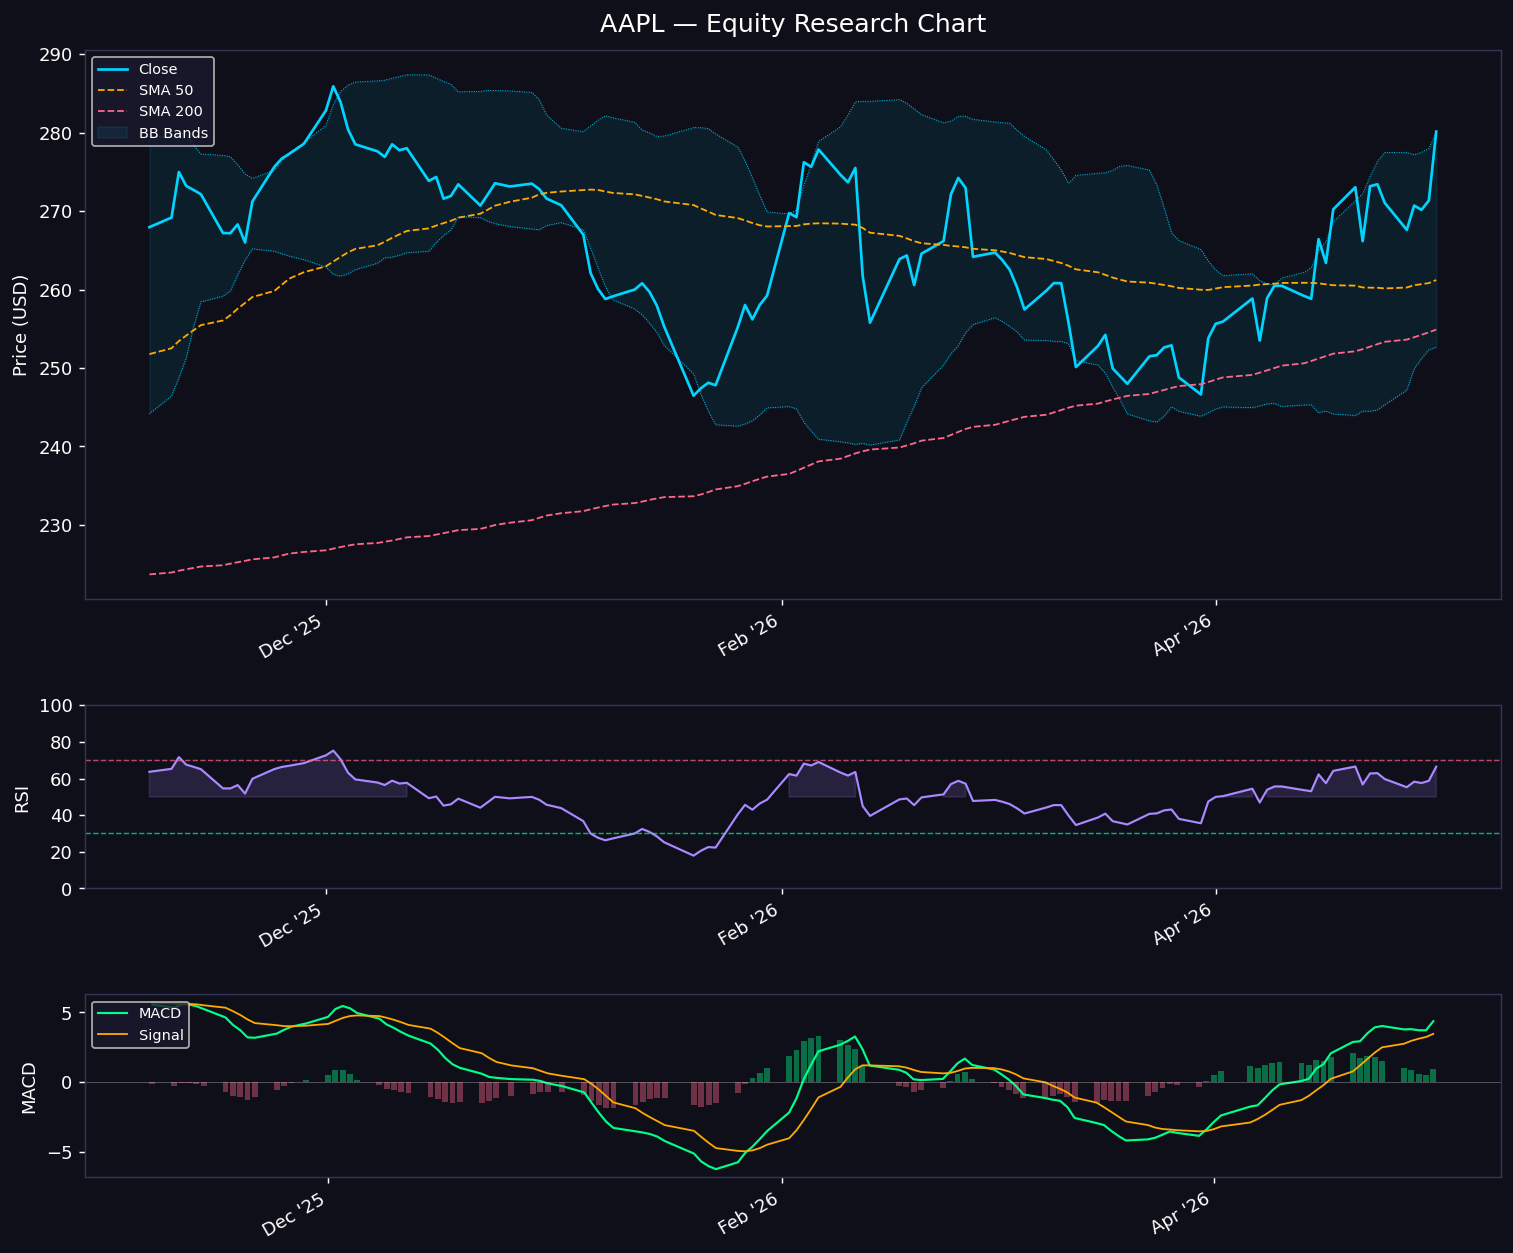

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import base64
from io import BytesIO
from datetime import datetime

# ============================================================
# BONUS — Equity Research Brief (HTML Report)
# ============================================================

def generate_chart(df: pd.DataFrame, ticker: str) -> str:
    """Generates a price + indicator chart and returns it as base64 HTML img tag."""
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10),
                                         gridspec_kw={"height_ratios": [3, 1, 1]})
    fig.patch.set_facecolor("#0f0f1a")
    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor("#0f0f1a")
        ax.tick_params(colors="white")
        ax.yaxis.label.set_color("white")
        ax.xaxis.label.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#333355")

    plot_df = df.tail(120).copy()

    # ── Price + Bollinger Bands + SMAs ────────────────────────
    ax1.plot(plot_df.index, plot_df["Close"],    color="#00d4ff", linewidth=1.5, label="Close")
    ax1.plot(plot_df.index, plot_df["SMA_50"],   color="#ffaa00", linewidth=1,   label="SMA 50",  linestyle="--")
    ax1.plot(plot_df.index, plot_df["SMA_200"],  color="#ff6688", linewidth=1,   label="SMA 200", linestyle="--")
    ax1.fill_between(plot_df.index, plot_df["BB_Upper"], plot_df["BB_Lower"],
                     alpha=0.08, color="#00d4ff", label="BB Bands")
    ax1.plot(plot_df.index, plot_df["BB_Upper"], color="#00d4ff", linewidth=0.5, linestyle=":")
    ax1.plot(plot_df.index, plot_df["BB_Lower"], color="#00d4ff", linewidth=0.5, linestyle=":")
    ax1.set_title(f"{ticker} — Equity Research Chart", color="white", fontsize=14, pad=10)
    ax1.legend(loc="upper left", facecolor="#1a1a2e", labelcolor="white", fontsize=8)
    ax1.set_ylabel("Price (USD)", color="white")

    # ── RSI ───────────────────────────────────────────────────
    ax2.plot(plot_df.index, plot_df["RSI_14"], color="#aa88ff", linewidth=1.2)
    ax2.axhline(70, color="#ff6688", linewidth=0.8, linestyle="--", alpha=0.7)
    ax2.axhline(30, color="#00ff88", linewidth=0.8, linestyle="--", alpha=0.7)
    ax2.fill_between(plot_df.index, plot_df["RSI_14"], 50,
                     where=plot_df["RSI_14"] >= 50, alpha=0.15, color="#aa88ff")
    ax2.set_ylabel("RSI", color="white")
    ax2.set_ylim(0, 100)

    # ── MACD ──────────────────────────────────────────────────
    ax3.plot(plot_df.index, plot_df["MACD"],        color="#00ff88", linewidth=1.2, label="MACD")
    ax3.plot(plot_df.index, plot_df["MACD_Signal"], color="#ffaa00", linewidth=1.0, label="Signal")
    ax3.bar(plot_df.index, plot_df["MACD_Hist"],
            color=["#00ff88" if v >= 0 else "#ff6688" for v in plot_df["MACD_Hist"]],
            alpha=0.4, width=0.8)
    ax3.axhline(0, color="white", linewidth=0.5, alpha=0.3)
    ax3.set_ylabel("MACD", color="white")
    ax3.legend(loc="upper left", facecolor="#1a1a2e", labelcolor="white", fontsize=8)

    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", color="white")

    plt.tight_layout(pad=2)

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=130, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img_b64}" style="width:100%;border-radius:8px;">'


def generate_report(ticker: str, summary: dict, sentiment: SentimentSummary,
                    signal: SignalOutput, news: list, df: pd.DataFrame) -> str:
    """Generates a styled one-page HTML equity research brief."""

    chart_html = generate_chart(df, ticker)
    top_headlines = sentiment.results[:3]
    sentiment_color = {"positive": "#00ff88", "negative": "#ff6688", "neutral": "#ffaa00"}
    signal_color    = {"Buy": "#00ff88", "Hold": "#ffaa00", "Sell": "#ff6688"}

    headlines_html = ""
    for h in top_headlines:
        color = sentiment_color.get(h.sentiment, "white")
        headlines_html += f"""
        <div style="border-left:3px solid {color};padding:8px 12px;margin:8px 0;background:#1a1a2e;">
            <span style="color:{color};font-weight:bold;font-size:11px;">{h.sentiment.upper()} ({h.confidence})</span><br>
            <span style="color:#e0e0e0;">{h.headline}</span><br>
            <span style="color:#888;font-size:11px;font-style:italic;">{h.brief_reason}</span>
        </div>"""

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>{ticker} Equity Research Brief</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; background:#0f0f1a; color:#e0e0e0; margin:0; padding:24px; }}
  .container {{ max-width:900px; margin:0 auto; }}
  .header {{ border-bottom:2px solid #00d4ff; padding-bottom:12px; margin-bottom:20px; }}
  .header h1 {{ color:#00d4ff; margin:0; font-size:26px; }}
  .header p {{ color:#888; margin:4px 0 0; font-size:12px; }}
  .badge {{ display:inline-block; padding:4px 12px; border-radius:20px; font-weight:bold;
            font-size:13px; color:#0f0f1a; background:{signal_color.get(signal.signal)}; }}
  .section {{ background:#13132a; border-radius:8px; padding:16px 20px; margin:16px 0; }}
  .section h2 {{ color:#00d4ff; font-size:14px; text-transform:uppercase;
                 letter-spacing:1px; margin:0 0 12px; }}
  .grid {{ display:grid; grid-template-columns:repeat(3,1fr); gap:12px; }}
  .metric {{ background:#1a1a2e; border-radius:6px; padding:12px; text-align:center; }}
  .metric .val {{ font-size:20px; font-weight:bold; color:#00d4ff; }}
  .metric .lbl {{ font-size:11px; color:#888; margin-top:4px; }}
  .signal-box {{ text-align:center; padding:20px; }}
  .disclaimer {{ background:#1a1a0a; border:1px solid #ffaa00; border-radius:6px;
                 padding:12px 16px; font-size:11px; color:#aaa; margin-top:20px; }}
  .disclaimer strong {{ color:#ffaa00; }}
</style>
</head>
<body>
<div class="container">

  <div class="header">
    <h1>📊 {ticker} — Equity Research Brief</h1>
    <p>Generated: {datetime.now().strftime("%B %d, %Y %H:%M")} &nbsp;|&nbsp;
       Source: Automated LLM Research Pipeline &nbsp;|&nbsp; CONFIDENTIAL</p>
  </div>

  <div class="section">
    <h2>Company Snapshot</h2>
    <div class="grid">
      <div class="metric"><div class="val">${summary['current_price']}</div><div class="lbl">Current Price</div></div>
      <div class="metric"><div class="val">${summary['week_52_high']}</div><div class="lbl">52W High</div></div>
      <div class="metric"><div class="val">${summary['week_52_low']}</div><div class="lbl">52W Low</div></div>
      <div class="metric"><div class="val">{summary['pe_ratio'] or 'N/A'}</div><div class="lbl">P/E Ratio</div></div>
      <div class="metric"><div class="val">{summary['ytd_return_pct']}%</div><div class="lbl">YTD Return</div></div>
      <div class="metric"><div class="val" style="color:{'#00ff88' if summary['overall_momentum']=='BULLISH' else '#ff6688'};">
        {summary['overall_momentum']}</div><div class="lbl">Momentum</div></div>
    </div>
  </div>

  <div class="section">
    <h2>Technical Outlook</h2>
    {chart_html}
    <p style="color:#aaa;font-size:12px;margin-top:8px;">
      SMA50: <b style="color:#ffaa00">${summary['latest_indicators']['SMA_50']}</b> &nbsp;|&nbsp;
      SMA200: <b style="color:#ff6688">${summary['latest_indicators']['SMA_200']}</b> &nbsp;|&nbsp;
      RSI: <b style="color:#aa88ff">{summary['latest_indicators']['RSI_14']}</b> &nbsp;|&nbsp;
      MACD: <b style="color:#00ff88">{summary['latest_indicators']['MACD']}</b>
    </p>
  </div>

  <div class="section">
    <h2>News Sentiment — Top 3 Headlines</h2>
    {headlines_html}
    <p style="margin-top:12px;font-size:12px;color:#aaa;">
      Overall sentiment: <b style="color:{sentiment_color.get(sentiment.overall_label)}">
      {sentiment.overall_label.upper()}</b> (score: {sentiment.overall_score})
    </p>
  </div>

  <div class="section">
    <h2>LLM Recommendation</h2>
    <div class="signal-box">
      <div class="badge">{signal.signal.upper()}</div>
      <p style="margin-top:16px;color:#ccc;line-height:1.7;text-align:left;">
        {signal.justification}
      </p>
    </div>
  </div>

  <div class="disclaimer">
    <strong>⚠️ Risk Disclaimer:</strong> This report is generated by an automated AI pipeline
    for research and assessment purposes only. It does not constitute financial advice,
    investment recommendations, or an offer to buy or sell any security. Past performance
    is not indicative of future results. Always consult a qualified financial advisor before
    making investment decisions. The authors accept no liability for actions taken based
    on this report.
  </div>

</div>
</body>
</html>"""
    return html


# --- Generate and display the report ---
report_html = generate_report(TICKER, summary, sentiment_summary, signal_output, news, df)

# Save to file
with open("equity_report.html", "w", encoding="utf-8") as f:
    f.write(report_html)

# Display inline in Colab
from IPython.display import HTML
print("✅ Report generated — equity_report.html saved")
HTML(report_html)